In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:

# 1. LOAD DATA
df = pd.read_csv('/home/ciline/Téléchargements/ship_fuel_efficiency.csv')


In [5]:

# 2. FEATURE SELECTION
# We use distance to predict fuel consumption
X = df[['distance']] 
y = df['fuel_consumption']


In [6]:

# 3. TRAIN/TEST SPLIT
# We use 80% of data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:

# 4. INITIALIZE AND TRAIN THE MODEL
model = LinearRegression()
model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:

# 5. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 6. EVALUATION METRICS
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- MODEL PERFORMANCE ---")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")


--- MODEL PERFORMANCE ---
Coefficient (Slope): 42.57
Intercept: -1660.09
R-squared Score: 0.9055
Mean Squared Error: 2543635.64


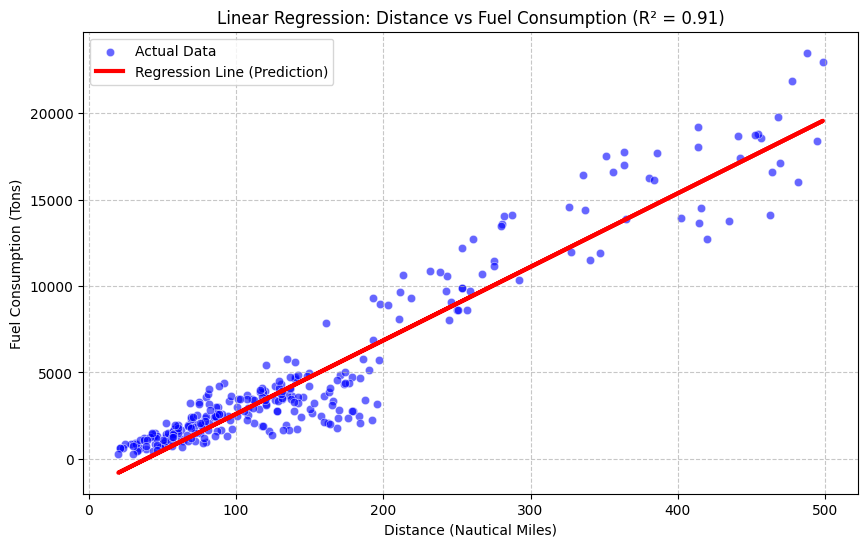

In [9]:

# 7. VISUALIZATION
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['distance'], y=y_test, color='blue', label='Actual Data', alpha=0.6)
plt.plot(X_test['distance'], y_pred, color='red', linewidth=3, label='Regression Line (Prediction)')
plt.title(f'Linear Regression: Distance vs Fuel Consumption (R² = {r2:.2f})')
plt.xlabel('Distance (Nautical Miles)')
plt.ylabel('Fuel Consumption (Tons)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()